# MobileNetV2 Quantization Analysis on GTSRB

This notebook evaluates MobileNetV2 under resource-constrained deployment settings using "FP32, FP16, and INT8" representations.

The experiments include:
- ROI-based preprocessing
- Post-training quantization
- Accuracy and calibration analysis
- Inference time benchmarking
- Class-wise error analysis
- Confusion matrix comparison

In [1]:
import os
import time
import random
import pathlib
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [ ]:
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

DATASET_DIR = PROJECT_ROOT / "dataset"
MODELS_DIR = PROJECT_ROOT / "models"
RESULTS_DIR = PROJECT_ROOT / "results"

FP32_MODEL_PATH = MODELS_DIR / "mobilenetv2_roi_fp32_best.keras"
INT8_MODEL_PATH = MODELS_DIR / "mobilenetv2_roi_int8.tflite"
INT8_LARGE_MODEL_PATH = MODELS_DIR / "mobilenetv2_roi_int8_large_rep.tflite"
FP16_MODEL_PATH = MODELS_DIR / "mobilenetv2_roi_fp16.tflite"

In [16]:
MODELS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

In [ ]:
"""
import os

print(os.path.exists("mobilenetv2_roi_fp32_best.keras"))
"""

True


In [8]:
import tensorflow as tf

model = tf.keras.models.load_model(FP32_MODEL_PATH)
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 43)             │        55,083 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,146,115 (23.45 MB)

 Trainable params: 1,916,523 (7.31 MB)

 Non-trainable params: 396,544 (1.51 MB)

 Optimizer params: 3,833,048 (14.62 MB)

In [4]:
seed = 42

random.seed(seed)
np.random.seed(seed)
tf.random.set_seed(seed)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


### Dataset

In [9]:
TRAIN_CSV_PATH = DATASET_DIR / "Train.csv"
TEST_CSV_PATH = DATASET_DIR / "Test.csv"
META_CSV_PATH = DATASET_DIR / "Meta.csv"
TRAIN_IMAGES_DIR = DATASET_DIR / "Train"
TEST_IMAGES_DIR = DATASET_DIR / "Test"

trainDf = pd.read_csv(TRAIN_CSV_PATH)
testDf = pd.read_csv(TEST_CSV_PATH)
metaDf = pd.read_csv(META_CSV_PATH)

print(trainDf.shape)
print(testDf.shape)
print(metaDf.shape)

trainDf.head()

(39209, 8)
(12630, 8)
(43, 5)


,Width,Height,Roi.X1,Roi.Y1,Roi.X2,Roi.Y2,ClassId,Path
0,27,26,5,5,22,20,20,Train/20/00020_00000_00000.png
1,28,27,5,6,23,22,20,Train/20/00020_00000_00001.png
2,29,26,6,5,24,21,20,Train/20/00020_00000_00002.png
3,28,27,5,6,23,22,20,Train/20/00020_00000_00003.png
4,28,26,5,5,23,21,20,Train/20/00020_00000_00004.png


- A noticeable gap appeared between validation and test accuracy in the initial experiments!
  Most likely caused by differences in how the train/validation and test images were processed.

- To make the preprocessing more consistent, ROI-based cropping was applied before resizing.  
  The image is first cropped to the traffic sign region, then resized to the target input size.

In [ ]:
trainDf["fullPath"] = trainDf["Path"].apply(lambda x: str(DATASET_DIR / x))
testDf["fullPath"] = testDf["Path"].apply(lambda x: str(DATASET_DIR / x))

print(trainDf["fullPath"].iloc[0])
print(os.path.exists(trainDf["fullPath"].iloc[0]))

/Users/hkaanozsoy/Desktop/ML - Writing/project/dataset/Train/20/00020_00000_00000.png
True


### Train - Validation Split

In [11]:
numClasses = 43 # dataset contains 43 traffic signs
imageSize = 96  # provide the images to the model in 96*96 dimensions (resized)
batchSize = 32

trainPaths, valPaths, trainLabels, valLabels, trainRois, valRois = train_test_split(
    trainDf["fullPath"].to_numpy(),
    trainDf["ClassId"].to_numpy(dtype=np.int32),
    trainDf[["Roi.X1", "Roi.Y1", "Roi.X2", "Roi.Y2"]].to_numpy(dtype=np.int32),
    test_size=0.15,
    random_state=seed,
    stratify=trainDf["ClassId"].to_numpy(dtype=np.int32)
)

testPaths = testDf["fullPath"].to_numpy()
testLabels = testDf["ClassId"].to_numpy(dtype=np.int32)
testRois = testDf[["Roi.X1", "Roi.Y1", "Roi.X2", "Roi.Y2"]].to_numpy(dtype=np.int32)

print("Train:", len(trainPaths))
print("Validation:", len(valPaths))
print("Test:", len(testPaths))

Train: 33327
Validation: 5882
Test: 12630


### ROI-Based Image Preprocessing

Traffic sign images are cropped using the provided ROI coordinates before resizing.
This allows the model to focus more directly on the sign region and reduces background noise.

- All images are resized to 96×96 and normalized using the MobileNetV2 preprocessing function.

In [12]:
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

"""
def loadImage(imagePath, label):
    image = tf.io.read_file(imagePath)
    image = tf.image.decode_png(image, channels=3)
    image = tf.image.resize(image, [imageSize, imageSize])
    image = preprocess_input(image)
    return image, label
"""

def loadImageWithRoi(imagePath, label, roi):
    image = tf.io.read_file(imagePath)
    image = tf.image.decode_png(image, channels=3)

    x1 = tf.cast(roi[0], tf.int32)
    y1 = tf.cast(roi[1], tf.int32)
    x2 = tf.cast(roi[2], tf.int32)
    y2 = tf.cast(roi[3], tf.int32)

    cropWidth = x2 - x1
    cropHeight = y2 - y1

    image = tf.image.crop_to_bounding_box(
        image,
        offset_height=y1,
        offset_width=x1,
        target_height=cropHeight,
        target_width=cropWidth
    )

    image = tf.image.resize(image, [imageSize, imageSize])
    image = preprocess_input(image)

    return image, label

In [13]:
"""
def createDataset(paths, labels, shuffle=False):
    dataset = tf.data.Dataset.from_tensor_slices((paths, labels))
    
    if shuffle:
        dataset = dataset.shuffle(buffer_size=len(paths), seed=seed)
    
    dataset = dataset.map(loadImage, num_parallel_calls=tf.data.AUTOTUNE)
    dataset = dataset.batch(batchSize)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)
    
    return dataset
"""

def createDatasetWithRoi(paths, labels, rois, shuffle=False):
    dataset = tf.data.Dataset.from_tensor_slices((paths, labels, rois))

    if shuffle:
        dataset = dataset.shuffle(buffer_size=len(paths), seed=seed)

    dataset = dataset.map(loadImageWithRoi, num_parallel_calls=tf.data.AUTOTUNE)
    dataset = dataset.batch(batchSize)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)

    return dataset

In [14]:
trainDs = createDatasetWithRoi(trainPaths, trainLabels, trainRois, shuffle=True)
valDs = createDatasetWithRoi(valPaths, valLabels, valRois)
testDs = createDatasetWithRoi(testPaths, testLabels, testRois)

### MobileNetV2

#### ImageNet pretrained backbone

In [ ]:
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2

baseModel = MobileNetV2(
    input_shape=(imageSize, imageSize, 3),
    include_top=False,  # created my own classifier
    weights="imagenet"  # transfer learning from ImageNet
)

baseModel.trainable = False

inputs = layers.Input(shape=(imageSize, imageSize, 3))

x = baseModel(inputs, training=False)   # MobileNetV2 as a "feature extractor"

# (None, 3, 3, 1280) --> (None, 1280)
x = layers.GlobalAveragePooling2D()(x)
# Flatten also can be used but with many more parameters..

# to reduce overfitting
x = layers.Dropout(0.3)(x)

# 43 output --> 43 class (softmax --> probability distribution)
outputs = layers.Dense(numClasses, activation="softmax")(x)

model = models.Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 43)             │        55,083 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,313,067 (8.82 MB)

 Trainable params: 55,083 (215.17 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

### First training --> Only classifier head

- Only GAP --> Dropout --> Dense layer is being learned

- Learning classification: using alreadyb extracted features

In [ ]:
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        str(FP32_MODEL_PATH),
        monitor="val_accuracy",
        save_best_only=True,
        mode="max",
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=5,
        restore_best_weights=True,
        mode="max"
    )
]

In [15]:
historyHead = model.fit(
    trainDs,
    validation_data=valDs,
    epochs=15,
    callbacks=callbacks
)

Epoch 1/15
1041/1042 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.5438 - loss: 1.6007
Epoch 1: val_accuracy improved from None to 0.86569, saving model to mobilenetv2_roi_fp32_best.keras

Epoch 1: finished saving model to mobilenetv2_roi_fp32_best.keras
1042/1042 ━━━━━━━━━━━━━━━━━━━━ 26s 24ms/step - accuracy: 0.6873 - loss: 1.0227 - val_accuracy: 0.8657 - val_loss: 0.4419
Epoch 2/15
1041/1042 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.8362 - loss: 0.5118
Epoch 2: val_accuracy improved from 0.86569 to 0.90479, saving model to mobilenetv2_roi_fp32_best.keras

Epoch 2: finished saving model to mobilenetv2_roi_fp32_best.keras
1042/1042 ━━━━━━━━━━━━━━━━━━━━ 24s 23ms/step - accuracy: 0.8414 - loss: 0.4901 - val_accuracy: 0.9048 - val_loss: 0.3257
Epoch 3/15
1041/1042 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.8664 - loss: 0.4069
Epoch 3: val_accuracy improved from 0.90479 to 0.90751, saving model to mobilenetv2_roi_fp32_best.keras

Epoch 3: finished saving model to mobilenetv2_r

- The main MobileNetV2 backbone was kept frozen.  
  Only the final classification layers were trained first.

- During training:
    - learned fairly quickly in the beginning -> validation accuracy reached 85.8% at Epoch 1
    - around 92.9% by Epoch 6
    - best validation result observed at Epoch 14 -> 93.71%

- `ModelCheckpoint` automatically saved the best-performing model as: `mobilenetv2_fp32_best.keras`

- Epoch 15 did not improve the validation score, so the checkpoint was not updated.


- training accuracy stayed around ~91%, while validation accuracy reached ~93–94%.
    - Dropout(0.3) was active during training, but disabled during validation.  
    - Validation therefore becomes slightly "easier" for the model.

### Fine-Tuning

- During fine-tuning, the earlier layers remained mostly frozen, while the last layers of the MobileNetV2 backbone were unfrozen and updated with a smaller learning rate.

- The earlier layers already capture general visual patterns such as edges and shapes.  
The later layers are more task-specific.

- Fine-tuning helps adapt ImageNet features to the traffic sign classification task.


In [16]:
baseModel.trainable = True

fineTuneAt = 100

for layer in baseModel.layers[:fineTuneAt]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 43)             │        55,083 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,313,067 (8.82 MB)

 Trainable params: 1,916,523 (7.31 MB)

 Non-trainable params: 396,544 (1.51 MB)

In [ ]:
callbacksFine = [
    tf.keras.callbacks.ModelCheckpoint(
        #"mobilenetv2_fp32_best.keras",
        str(FP32_MODEL_PATH),
        monitor="val_accuracy",
        save_best_only=True,
        mode="max",
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=5,
        restore_best_weights=True,
        mode="max"
    )
]

historyFine = model.fit(
    trainDs,
    validation_data=valDs,
    epochs=20,
    callbacks=callbacksFine
)

Epoch 1/20
1042/1042 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.5165 - loss: 4.0946
Epoch 1: val_accuracy improved from None to 0.85464, saving model to mobilenetv2_roi_fp32_best.keras

Epoch 1: finished saving model to mobilenetv2_roi_fp32_best.keras
1042/1042 ━━━━━━━━━━━━━━━━━━━━ 44s 39ms/step - accuracy: 0.6122 - loss: 2.6341 - val_accuracy: 0.8546 - val_loss: 0.5029
Epoch 2/20
1041/1042 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.7614 - loss: 1.0742
Epoch 2: val_accuracy improved from 0.85464 to 0.89884, saving model to mobilenetv2_roi_fp32_best.keras

Epoch 2: finished saving model to mobilenetv2_roi_fp32_best.keras
1042/1042 ━━━━━━━━━━━━━━━━━━━━ 41s 39ms/step - accuracy: 0.7798 - loss: 0.9388 - val_accuracy: 0.8988 - val_loss: 0.3306
Epoch 3/20
1042/1042 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.8345 - loss: 0.6097
Epoch 3: val_accuracy improved from 0.89884 to 0.92877, saving model to mobilenetv2_roi_fp32_best.keras

Epoch 3: finished saving model to mobilenetv2_r

So,
- Head-training: 93.7%
- After fine-tuning: 99.08% (val acc) | (train acc. --> 99.17%)

- No overfitting

- Val loss → 0.0288 (very good)

### Test-set performans

In [ ]:
#model = tf.keras.models.load_model("mobilenetv2_fp32_best.keras")
model = tf.keras.models.load_model(FP32_MODEL_PATH)

testLoss, testAccuracy = model.evaluate(testDs)

print("FP32 MobileNetV2 Test Accuracy:", testAccuracy)
print("FP32 MobileNetV2 Test Loss:", testLoss)

395/395 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.9109 - loss: 0.4669
FP32 MobileNetV2 Test Accuracy: 0.910926342010498
FP32 MobileNetV2 Test Loss: 0.46693241596221924


In [11]:
def getPredictionsKeras(model, dataset):
    allProbabilities = []
    allLabels = []
    
    for images, labels in dataset:
        probabilities = model.predict(images, verbose=0)
        allProbabilities.append(probabilities)
        allLabels.append(labels.numpy())
    
    allProbabilities = np.concatenate(allProbabilities, axis=0)
    allLabels = np.concatenate(allLabels, axis=0)
    allPredictions = np.argmax(allProbabilities, axis=1)
    
    return allLabels, allPredictions, allProbabilities

In [12]:
yTrue, yPred, yProb = getPredictionsKeras(model, testDs)

print("Accuracy:", accuracy_score(yTrue, yPred))
print(classification_report(yTrue, yPred, digits=4))

Accuracy: 0.9109263657957245
              precision    recall  f1-score   support

           0     0.8387    0.4333    0.5714        60
           1     0.8898    0.8639    0.8767       720
           2     0.8463    0.9547    0.8972       750
           3     0.9527    0.8511    0.8991       450
           4     0.9581    0.9348    0.9463       660
           5     0.8338    0.8683    0.8507       630
           6     0.9701    0.8667    0.9155       150
           7     0.9275    0.9378    0.9326       450
           8     0.8909    0.8889    0.8899       450
           9     0.9637    0.9958    0.9795       480
          10     0.9954    0.9879    0.9916       660
          11     0.8979    0.9214    0.9095       420
          12     0.9881    0.9594    0.9735       690
          13     0.9741    0.9944    0.9842       720
          14     0.9962    0.9667    0.9812       270
          15     0.9856    0.9810    0.9833       210
          16     0.9933    0.9933    0.9933       15

- !! Validation accuracy was 99.08% while test accuracy was 86.66%. (ON THE FIRST ATTEMPT - before ROI)

### ECE - Expected Calibration Error

- It measures how well the model's confidence scores match its actual accuracy.  
- A lower ECE generally indicates better-calibrated predictions.

In [ ]:
def computeEce(yTrue, yProb, numBins=15):
    confidences = np.max(yProb, axis=1)
    predictions = np.argmax(yProb, axis=1)
    accuracies = predictions == yTrue
    
    binBoundaries = np.linspace(0.0, 1.0, numBins + 1)
    ece = 0.0
    
    for binIndex in range(numBins):
        binLower = binBoundaries[binIndex]
        binUpper = binBoundaries[binIndex + 1]
        
        inBin = (confidences > binLower) & (confidences <= binUpper)
        proportionInBin = np.mean(inBin)
        
        if proportionInBin > 0:
            accuracyInBin = np.mean(accuracies[inBin])
            confidenceInBin = np.mean(confidences[inBin])
            ece += proportionInBin * np.abs(accuracyInBin - confidenceInBin)
    
    return ece

In [14]:
fp32Ece = computeEce(yTrue, yProb, numBins=15)

print("FP32 MobileNetV2 ECE:", fp32Ece)

FP32 MobileNetV2 ECE: 0.05764536997060028


### Model size olcme

In [ ]:
def getFileSizeMb(filePath):
    return os.path.getsize(filePath) / (1024 * 1024)

#fp32ModelPath = "mobilenetv2_fp32_best.keras"
# fp32ModelPath = "mobilenetv2_roi_fp32_best.keras"
fp32SizeMb = getFileSizeMb(FP32_MODEL_PATH)

print("FP32 MobileNetV2 model size MB:", fp32SizeMb)

FP32 MobileNetV2 model size MB: 24.04619598388672


### Inference Time Measurement

In [16]:
def measureKerasInferenceTime(model, dataset, warmupBatches=5, measuredBatches=30):
    batchTimes = []
    
    for batchIndex, (images, _) in enumerate(dataset):
        if batchIndex < warmupBatches:
            _ = model.predict(images, verbose=0)
            continue
        
        startTime = time.time()
        _ = model.predict(images, verbose=0)
        endTime = time.time()
        
        batchTimes.append((endTime - startTime) / images.shape[0])
        
        if len(batchTimes) >= measuredBatches:
            break
    
    return np.mean(batchTimes) * 1000

In [17]:
fp32LatencyMs = measureKerasInferenceTime(model, testDs)

print("FP32 MobileNetV2 inference time ms/image:", fp32LatencyMs)

FP32 MobileNetV2 inference time ms/image: 1.0708622634410858


### Sonuc Tablosu

In [18]:
results = pd.DataFrame([
    {
        "Model": "MobileNetV2",
        "Precision": "FP32",
        "Accuracy": accuracy_score(yTrue, yPred),
        "ECE": fp32Ece,
        "Size_MB": fp32SizeMb,
        "Inference_ms_per_image": fp32LatencyMs
    }
])

results

,Model,Precision,Accuracy,ECE,Size_MB,Inference_ms_per_image
0,MobileNetV2,FP32,0.910926,0.057645,24.046196,1.070862


### FP32 Results Before ROI Cropping
- Accuracy: 86.66%
- ECE: 0.0925

### FP32 Results After ROI-Based Preprocessing
- Accuracy: 91.09%
- ECE: 0.0576

#### - ROI preprocessing clearly improved the model.

- Accuracy increased by +4.43 points
- ECE improved from 0.0925 to 0.0576

- noticeable improvement overall.

- Validation accuracy is 98.98%, test accuracy is 91.09%.
- This difference is still significant. The model performs very well on the training/validation side, but the official test set is more difficult or there's a difference in dispersion.

## Quantization

In [ ]:
model = tf.keras.models.load_model(FP32_MODEL_PATH)
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 43)             │        55,083 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,146,115 (23.45 MB)

 Trainable params: 1,916,523 (7.31 MB)

 Non-trainable params: 396,544 (1.51 MB)

 Optimizer params: 3,833,048 (14.62 MB)

- INT8 PTQ icin kucuk bir calibration/representative set gerekiyor

In [19]:
def representativeDataset():
    for images, _ in trainDs.take(100):
        yield [tf.cast(images, tf.float32)]

### Convert to INT8 TFLite

In [ ]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)

# Without this, quantization often doesn't come into play.
# DEFAULT enables standard optimizations aimed at reducing model size and inference cost.
converter.optimizations = [tf.lite.Optimize.DEFAULT]

# A representative dataset is used to estimate activation ranges
converter.representative_dataset = representativeDataset

# Convert supported operations to INT8 where possible
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]

# Keep input and output tensors in float32 format
# This way we can provide a preprocessed float32 image when testing.
converter.inference_input_type = tf.float32
converter.inference_output_type = tf.float32

tfliteInt8Model = converter.convert()

INFO:tensorflow:Assets written to: /var/folders/vl/_gbpkf0n6gnfq24qb5_m_7rw0000gn/T/tmpfy_4arpw/assets


INFO:tensorflow:Assets written to: /var/folders/vl/_gbpkf0n6gnfq24qb5_m_7rw0000gn/T/tmpfy_4arpw/assets


Saved artifact at '/var/folders/vl/_gbpkf0n6gnfq24qb5_m_7rw0000gn/T/tmpfy_4arpw'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 96, 96, 3), dtype=tf.float32, name='input_layer_3')
Output Type:
  TensorSpec(shape=(None, 43), dtype=tf.float32, name=None)
Captures:
  4982842064: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4982845904: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4982841680: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4982843984: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4982842448: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4982845712: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4982847824: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4982842640: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4982846480: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4982847440: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4982846864: TensorSp

/Users/hkaanozsoy/Desktop/ML - Writing/code/ml_env/lib/python3.11/site-packages/tensorflow/lite/python/convert.py:846: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
W0000 00:00:1778781939.477746  283099 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1778781939.477756  283099 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
I0000 00:00:1778781939.477972  283099 reader.cc:83] Reading SavedModel from: /var/folders/vl/_gbpkf0n6gnfq24qb5_m_7rw0000gn/T/tmpfy_4arpw
I0000 00:00:1778781939.481507  283099 reader.cc:52] Reading meta graph with tags { serve }
I0000 00:00:1778781939.481513  283099 reader.cc:147] Reading SavedModel debug info (if present) from: /var/folders/vl/_gbpkf0n6gnfq24qb5_m_7rw0000gn/T/tmpfy_4arpw
I0000 00:00:1778781939.511904  283099 mlir_graph_optimization_pass.cc:437] MLIR V1 optimization pass is not enabled
I0000 00:00:1778781939.520255  283099 loader.cc:236] Resto

float32 input -> Quantized at the model input -> Internal operations run in INT8 ->
Finally, the output is converted back to float32

### Save INT8 model

In [ ]:
# int8ModelPath = "mobilenetv2_roi_int8.tflite"

with open(INT8_MODEL_PATH, "wb") as f:
    f.write(tfliteInt8Model)

int8SizeMb = os.path.getsize(INT8_MODEL_PATH) / (1024 * 1024)

print("INT8 model saved:", INT8_MODEL_PATH)
print("INT8 model size MB:", int8SizeMb)

INT8 model saved: mobilenetv2_roi_int8.tflite
INT8 model size MB: 2.6572418212890625


### TFLite Prediction 

In [20]:
def getPredictionsTflite(tfliteModelPath, dataset):
    interpreter = tf.lite.Interpreter(model_path=tfliteModelPath)
    interpreter.allocate_tensors()

    inputDetails = interpreter.get_input_details()
    outputDetails = interpreter.get_output_details()

    allProbabilities = []
    allLabels = []

    for images, labels in dataset:
        imagesNp = images.numpy().astype(np.float32)
        labelsNp = labels.numpy()

        for i in range(imagesNp.shape[0]):
            inputImage = np.expand_dims(imagesNp[i], axis=0)

            interpreter.set_tensor(inputDetails[0]["index"], inputImage)
            interpreter.invoke()

            output = interpreter.get_tensor(outputDetails[0]["index"])[0]

            allProbabilities.append(output)
            allLabels.append(labelsNp[i])

    allProbabilities = np.array(allProbabilities)
    allLabels = np.array(allLabels)
    allPredictions = np.argmax(allProbabilities, axis=1)

    return allLabels, allPredictions, allProbabilities

### INT8 accuracy ve ECE

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

int8YTrue, int8YPred, int8YProb = getPredictionsTflite(
    INT8_MODEL_PATH,
    testDs
)

int8Accuracy = accuracy_score(int8YTrue, int8YPred)
int8Ece = computeEce(int8YTrue, int8YProb)

print("INT8 MobileNetV2 Test Accuracy:", int8Accuracy)
print("INT8 MobileNetV2 ECE:", int8Ece)

print(classification_report(int8YTrue, int8YPred, digits=4))

/Users/hkaanozsoy/Desktop/ML - Writing/code/ml_env/lib/python3.11/site-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


INT8 MobileNetV2 Test Accuracy: 0.6521773555027712
INT8 MobileNetV2 ECE: 0.24366586750826003
              precision    recall  f1-score   support

           0     0.3800    0.3167    0.3455        60
           1     0.4186    0.9292    0.5772       720
           2     0.8164    0.5987    0.6908       750
           3     0.2209    0.4378    0.2936       450
           4     0.8797    0.2106    0.3399       660
           5     0.5800    0.5810    0.5805       630
           6     1.0000    0.0400    0.0769       150
           7     0.8414    0.5422    0.6595       450
           8     0.8198    0.2022    0.3244       450
           9     0.8889    0.5833    0.7044       480
          10     0.6926    0.8091    0.7463       660
          11     0.4746    0.8905    0.6192       420
          12     0.9734    0.8493    0.9071       690
          13     0.8794    0.9819    0.9278       720
          14     0.9799    0.9037    0.9403       270
          15     1.0000    0.9286    0.963

/Users/hkaanozsoy/Desktop/ML - Writing/code/ml_env/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/hkaanozsoy/Desktop/ML - Writing/code/ml_env/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/hkaanozsoy/Desktop/ML - Writing/code/ml_env/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this beha

### INT8 latency

In [27]:
def measureTfliteInferenceTime(tfliteModelPath, dataset, warmupSamples=100, measuredSamples=1000):
    interpreter = tf.lite.Interpreter(model_path=tfliteModelPath)
    interpreter.allocate_tensors()

    inputDetails = interpreter.get_input_details()
    outputDetails = interpreter.get_output_details()

    times = []
    seenSamples = 0

    for images, _ in dataset:
        imagesNp = images.numpy().astype(np.float32)

        for i in range(imagesNp.shape[0]):
            inputImage = np.expand_dims(imagesNp[i], axis=0)

            startTime = time.time()

            interpreter.set_tensor(inputDetails[0]["index"], inputImage)
            interpreter.invoke()
            _ = interpreter.get_tensor(outputDetails[0]["index"])

            endTime = time.time()

            if seenSamples >= warmupSamples:
                times.append(endTime - startTime)

            seenSamples += 1

            if len(times) >= measuredSamples:
                return np.mean(times) * 1000

    return np.mean(times) * 1000

In [ ]:
int8LatencyMs = measureTfliteInferenceTime(
    INT8_MODEL_PATH,
    testDs
)

print("INT8 MobileNetV2 latency ms/image:", int8LatencyMs)

/Users/hkaanozsoy/Desktop/ML - Writing/code/ml_env/lib/python3.11/site-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


INT8 MobileNetV2 latency ms/image: 0.3963432312011719


### Compare with values of FP32 model 

In [29]:
def getPredictionsKeras(model, dataset):
    allProbabilities = []
    allLabels = []

    for images, labels in dataset:
        probabilities = model.predict(images, verbose=0)
        allProbabilities.append(probabilities)
        allLabels.append(labels.numpy())

    allProbabilities = np.concatenate(allProbabilities, axis=0)
    allLabels = np.concatenate(allLabels, axis=0)
    allPredictions = np.argmax(allProbabilities, axis=1)

    return allLabels, allPredictions, allProbabilities

In [30]:
def measureKerasInferenceTime(model, dataset, warmupBatches=5, measuredBatches=30):
    batchTimes = []

    for batchIndex, (images, _) in enumerate(dataset):
        if batchIndex < warmupBatches:
            _ = model.predict(images, verbose=0)
            continue

        startTime = time.time()
        _ = model.predict(images, verbose=0)
        endTime = time.time()

        batchTimes.append((endTime - startTime) / images.shape[0])

        if len(batchTimes) >= measuredBatches:
            break

    return np.mean(batchTimes) * 1000

In [31]:
fp32YTrue, fp32YPred, fp32YProb = getPredictionsKeras(model, testDs)

fp32Accuracy = accuracy_score(fp32YTrue, fp32YPred)
fp32Ece = computeEce(fp32YTrue, fp32YProb)
fp32SizeMb = os.path.getsize("mobilenetv2_roi_fp32_best.keras") / (1024 * 1024)
fp32LatencyMs = measureKerasInferenceTime(model, testDs)

In [32]:
results = pd.DataFrame([
    {
        "Model": "MobileNetV2 ROI",
        "Precision": "FP32",
        "Accuracy": fp32Accuracy,
        "ECE": fp32Ece,
        "Size_MB": fp32SizeMb,
        "Inference_ms_per_image": fp32LatencyMs
    },
    {
        "Model": "MobileNetV2 ROI",
        "Precision": "INT8 PTQ",
        "Accuracy": int8Accuracy,
        "ECE": int8Ece,
        "Size_MB": int8SizeMb,
        "Inference_ms_per_image": int8LatencyMs
    }
])

results

,Model,Precision,Accuracy,ECE,Size_MB,Inference_ms_per_image
0,MobileNetV2 ROI,FP32,0.910926,0.057645,24.046196,1.089797
1,MobileNetV2 ROI,INT8 PTQ,0.652177,0.243666,2.657242,0.396343


- The model uses float32 input/output tensors while performing most internal operations in INT8 format, which is a common TensorFlow Lite setup.

- Calibration quality may still be affected by the combination of ROI preprocessing, MobileNetV2 fine-tuning, and batch normalization layers.

- One possible improvement, using a larger and more balanced representative dataset during calibration.  

### Enlarge the representative dataset

In [33]:
def representativeDatasetLarge():
    for images, _ in trainDs.take(300):
        yield [tf.cast(images, tf.float32)]

### Convert to INT8 again

In [34]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)

converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representativeDatasetLarge
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]

converter.inference_input_type = tf.float32
converter.inference_output_type = tf.float32

tfliteInt8ModelLarge = converter.convert()

INFO:tensorflow:Assets written to: /var/folders/vl/_gbpkf0n6gnfq24qb5_m_7rw0000gn/T/tmppac_ruyz/assets


INFO:tensorflow:Assets written to: /var/folders/vl/_gbpkf0n6gnfq24qb5_m_7rw0000gn/T/tmppac_ruyz/assets


Saved artifact at '/var/folders/vl/_gbpkf0n6gnfq24qb5_m_7rw0000gn/T/tmppac_ruyz'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 96, 96, 3), dtype=tf.float32, name='input_layer_3')
Output Type:
  TensorSpec(shape=(None, 43), dtype=tf.float32, name=None)
Captures:
  4982842064: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4982845904: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4982841680: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4982843984: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4982842448: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4982845712: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4982847824: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4982842640: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4982846480: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4982847440: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4982846864: TensorSp

/Users/hkaanozsoy/Desktop/ML - Writing/code/ml_env/lib/python3.11/site-packages/tensorflow/lite/python/convert.py:846: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
W0000 00:00:1778782057.816711  283099 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1778782057.816721  283099 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
I0000 00:00:1778782057.816846  283099 reader.cc:83] Reading SavedModel from: /var/folders/vl/_gbpkf0n6gnfq24qb5_m_7rw0000gn/T/tmppac_ruyz
I0000 00:00:1778782057.820261  283099 reader.cc:52] Reading meta graph with tags { serve }
I0000 00:00:1778782057.820348  283099 reader.cc:147] Reading SavedModel debug info (if present) from: /var/folders/vl/_gbpkf0n6gnfq24qb5_m_7rw0000gn/T/tmppac_ruyz
I0000 00:00:1778782057.858525  283099 loader.cc:236] Restoring SavedModel bundle.
I0000 00:00:1778782058.072026  283099 loader.cc:220] Running initialization op on SavedModel

In [ ]:
# int8LargeModelPath = "mobilenetv2_roi_int8_large_rep.tflite"

with open(INT8_LARGE_MODEL_PATH, "wb") as f:
    f.write(tfliteInt8ModelLarge)

print("INT8 large rep size MB:", os.path.getsize(INT8_LARGE_MODEL_PATH) / (1024 * 1024))

INT8 large rep size MB: 2.6572418212890625


### Evaluate again

In [ ]:
int8LargeYTrue, int8LargeYPred, int8LargeYProb = getPredictionsTflite(
    INT8_LARGE_MODEL_PATH,
    testDs
)

int8LargeAccuracy = accuracy_score(int8LargeYTrue, int8LargeYPred)
int8LargeEce = computeEce(int8LargeYTrue, int8LargeYProb)
int8LargeLatencyMs = measureTfliteInferenceTime(INT8_LARGE_MODEL_PATH, testDs)

print("INT8 large rep accuracy:", int8LargeAccuracy)
print("INT8 large rep ECE:", int8LargeEce)
print("INT8 large rep latency:", int8LargeLatencyMs)

/Users/hkaanozsoy/Desktop/ML - Writing/code/ml_env/lib/python3.11/site-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)
/Users/hkaanozsoy/Desktop/ML - Writing/code/ml_env/lib/python3.11/site-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


INT8 large rep accuracy: 0.6517814726840855
INT8 large rep ECE: 0.2431082382503239
INT8 large rep latency: 0.3824150562286377


- INT8 PTQ ayari, MobileNetV2 ROI modelini bozuyor!!

- FP16 quantization deneyelim..

### FP16 Quantization

In [37]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)

converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.target_spec.supported_types = [tf.float16]

tfliteFp16Model = converter.convert()

INFO:tensorflow:Assets written to: /var/folders/vl/_gbpkf0n6gnfq24qb5_m_7rw0000gn/T/tmpye_l_xib/assets


INFO:tensorflow:Assets written to: /var/folders/vl/_gbpkf0n6gnfq24qb5_m_7rw0000gn/T/tmpye_l_xib/assets


Saved artifact at '/var/folders/vl/_gbpkf0n6gnfq24qb5_m_7rw0000gn/T/tmpye_l_xib'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 96, 96, 3), dtype=tf.float32, name='input_layer_3')
Output Type:
  TensorSpec(shape=(None, 43), dtype=tf.float32, name=None)
Captures:
  4982842064: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4982845904: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4982841680: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4982843984: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4982842448: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4982845712: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4982847824: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4982842640: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4982846480: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4982847440: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4982846864: TensorSp

W0000 00:00:1778782234.686875  283099 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1778782234.686885  283099 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
I0000 00:00:1778782234.686990  283099 reader.cc:83] Reading SavedModel from: /var/folders/vl/_gbpkf0n6gnfq24qb5_m_7rw0000gn/T/tmpye_l_xib
I0000 00:00:1778782234.690470  283099 reader.cc:52] Reading meta graph with tags { serve }
I0000 00:00:1778782234.690473  283099 reader.cc:147] Reading SavedModel debug info (if present) from: /var/folders/vl/_gbpkf0n6gnfq24qb5_m_7rw0000gn/T/tmpye_l_xib
I0000 00:00:1778782234.726379  283099 loader.cc:236] Restoring SavedModel bundle.
I0000 00:00:1778782234.940262  283099 loader.cc:220] Running initialization op on SavedModel bundle at path: /var/folders/vl/_gbpkf0n6gnfq24qb5_m_7rw0000gn/T/tmpye_l_xib
I0000 00:00:1778782234.997685  283099 loader.cc:471] SavedModel load for tags { serve }; Status: success: OK. Took 310697 microseconds.


In [ ]:
# fp16ModelPath = "mobilenetv2_roi_fp16.tflite"

with open(FP16_MODEL_PATH, "wb") as f:
    f.write(tfliteFp16Model)

fp16SizeMb = os.path.getsize(FP16_MODEL_PATH) / (1024 * 1024)

print("FP16 model saved:", FP16_MODEL_PATH)
print("FP16 model size MB:", fp16SizeMb)

FP16 model saved: mobilenetv2_roi_fp16.tflite
FP16 model size MB: 4.400310516357422


In [ ]:
fp16YTrue, fp16YPred, fp16YProb = getPredictionsTflite(
    FP16_MODEL_PATH,
    testDs
)

fp16Accuracy = accuracy_score(fp16YTrue, fp16YPred)
fp16Ece = computeEce(fp16YTrue, fp16YProb)
fp16LatencyMs = measureTfliteInferenceTime(FP16_MODEL_PATH, testDs)

print("FP16 MobileNetV2 Accuracy:", fp16Accuracy)
print("FP16 MobileNetV2 ECE:", fp16Ece)
print("FP16 MobileNetV2 Latency:", fp16LatencyMs)

/Users/hkaanozsoy/Desktop/ML - Writing/code/ml_env/lib/python3.11/site-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)
/Users/hkaanozsoy/Desktop/ML - Writing/code/ml_env/lib/python3.11/site-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


FP16 MobileNetV2 Accuracy: 0.9093428345209817
FP16 MobileNetV2 ECE: 0.05893658933569683
FP16 MobileNetV2 Latency: 1.3721559047698975


In [40]:
results = pd.DataFrame([
    {
        "Model": "MobileNetV2 ROI",
        "Precision": "FP32",
        "Accuracy": fp32Accuracy,
        "ECE": fp32Ece,
        "Size_MB": fp32SizeMb,
        "Inference_ms_per_image": fp32LatencyMs
    },
    {
        "Model": "MobileNetV2 ROI",
        "Precision": "INT8 PTQ",
        "Accuracy": int8Accuracy,
        "ECE": int8Ece,
        "Size_MB": int8SizeMb,
        "Inference_ms_per_image": int8LatencyMs
    },
    {
        "Model": "MobileNetV2 ROI",
        "Precision": "FP16",
        "Accuracy": fp16Accuracy,
        "ECE": fp16Ece,
        "Size_MB": fp16SizeMb,
        "Inference_ms_per_image": fp16LatencyMs
    }
])

results

,Model,Precision,Accuracy,ECE,Size_MB,Inference_ms_per_image
0,MobileNetV2 ROI,FP32,0.910926,0.057645,24.046196,1.089797
1,MobileNetV2 ROI,INT8 PTQ,0.652177,0.243666,2.657242,0.396343
2,MobileNetV2 ROI,FP16,0.909343,0.058937,4.400311,1.372156


- FP16 provided a very good trade-off.
- Accuracy was almost preserved: 91.09% → 90.93%
- ECE was almost the same: 0.0576 → 0.0589
- Model size was significantly reduced: 24.05 MB → 4.40 MB
- But latency increased: 1.07 ms → 1.36 ms

- The latency increase is a bit strange, but it's possible. Because the FP16 acceleration might not be well supported on your device/hardware.

- INT8 PTQ provides efficiency gains, but it's not reliable in terms of prediction quality and calibration in this model.

### Class-wise Analysis

- Does quantization only reduce overall accuracy, or does it particularly affect certain classes more?

In [41]:
import numpy as np
import pandas as pd

def computeClassWiseAccuracy(yTrue, yPred, numClasses=43):
    rows = []

    for classId in range(numClasses):
        classMask = yTrue == classId
        support = np.sum(classMask)

        if support == 0:
            classAccuracy = np.nan
        else:
            classAccuracy = np.mean(yPred[classMask] == yTrue[classMask])

        rows.append({
            "ClassId": classId,
            "Support": support,
            "Class_Accuracy": classAccuracy
        })

    return pd.DataFrame(rows)

In [42]:
fp32ClassAcc = computeClassWiseAccuracy(fp32YTrue, fp32YPred, numClasses=43)
int8ClassAcc = computeClassWiseAccuracy(int8YTrue, int8YPred, numClasses=43)
fp16ClassAcc = computeClassWiseAccuracy(fp16YTrue, fp16YPred, numClasses=43)

In [43]:
classComparison = fp32ClassAcc.rename(columns={
    "Class_Accuracy": "FP32_Accuracy"
})

classComparison["INT8_Accuracy"] = int8ClassAcc["Class_Accuracy"]
classComparison["FP16_Accuracy"] = fp16ClassAcc["Class_Accuracy"]

classComparison["INT8_Drop"] = classComparison["FP32_Accuracy"] - classComparison["INT8_Accuracy"]
classComparison["FP16_Drop"] = classComparison["FP32_Accuracy"] - classComparison["FP16_Accuracy"]

classComparison.head()

,ClassId,Support,FP32_Accuracy,INT8_Accuracy,FP16_Accuracy,INT8_Drop,FP16_Drop
0,0,60,0.433333,0.316667,0.400000,0.116667,0.033333
1,1,720,0.863889,0.929167,0.859722,-0.065278,0.004167
2,2,750,0.954667,0.598667,0.952000,0.356000,0.002667
3,3,450,0.851111,0.437778,0.851111,0.413333,0.000000
4,4,660,0.934848,0.210606,0.931818,0.724242,0.003030


In [ ]:
# metaDf.head()

,Path,ClassId,ShapeId,ColorId,SignId
0,Meta/27.png,27,0,0,1.32
1,Meta/0.png,0,1,0,3.29
2,Meta/1.png,1,1,0,3.29
3,Meta/10.png,10,1,0,3.27
4,Meta/11.png,11,0,0,1.22


### The most degraded classes after INT8

In [44]:
worstInt8Classes = classComparison.sort_values(
    by="INT8_Drop",
    ascending=False
)

worstInt8Classes.head(10)

,ClassId,Support,FP32_Accuracy,INT8_Accuracy,FP16_Accuracy,INT8_Drop,FP16_Drop
32,32,60,1.000000,0.100000,1.000000,0.900000,0.000000
42,42,90,0.888889,0.000000,0.888889,0.888889,0.000000
6,6,150,0.866667,0.040000,0.886667,0.826667,-0.020000
4,4,660,0.934848,0.210606,0.931818,0.724242,0.003030
8,8,450,0.888889,0.202222,0.893333,0.686667,-0.004444
41,41,60,0.900000,0.433333,0.900000,0.466667,0.000000
19,19,60,0.850000,0.416667,0.850000,0.433333,0.000000
21,21,90,0.744444,0.322222,0.755556,0.422222,-0.011111
16,16,150,0.993333,0.573333,0.993333,0.420000,0.000000
3,3,450,0.851111,0.437778,0.851111,0.413333,0.000000


- INT8 PTQ severely breaks class-based behavior!
- In some classes, the model becomes almost completely dysfunctional.

### The most degraded classes after FP16

In [45]:
worstFp16Classes = classComparison.sort_values(
    by="FP16_Drop",
    ascending=False
)

worstFp16Classes.head(10)

,ClassId,Support,FP32_Accuracy,INT8_Accuracy,FP16_Accuracy,INT8_Drop,FP16_Drop
0,0,60,0.433333,0.316667,0.400000,0.116667,0.033333
30,30,150,0.753333,0.373333,0.733333,0.380000,0.020000
37,37,60,0.383333,0.300000,0.366667,0.083333,0.016667
20,20,90,0.611111,0.566667,0.600000,0.044444,0.011111
25,25,480,0.941667,0.935417,0.935417,0.006250,0.006250
18,18,390,0.848718,0.700000,0.843590,0.148718,0.005128
33,33,210,0.895238,0.652381,0.890476,0.242857,0.004762
11,11,420,0.921429,0.890476,0.916667,0.030952,0.004762
1,1,720,0.863889,0.929167,0.859722,-0.065278,0.004167
14,14,270,0.966667,0.903704,0.962963,0.062963,0.003704


- FP16 has hardly changed at all. Even the worst drop was minor.

In [46]:
displayColumns = [
    "ClassId",
    "Support",
    "FP32_Accuracy",
    "INT8_Accuracy",
    "INT8_Drop",
    "FP16_Accuracy",
    "FP16_Drop"
]

if "SignName" in classComparison.columns:
    displayColumns.append("SignName")

classComparison[displayColumns].sort_values(
    by="INT8_Drop",
    ascending=False
).head(15)

,ClassId,Support,FP32_Accuracy,INT8_Accuracy,INT8_Drop,FP16_Accuracy,FP16_Drop
32,32,60,1.000000,0.100000,0.900000,1.000000,0.000000
42,42,90,0.888889,0.000000,0.888889,0.888889,0.000000
6,6,150,0.866667,0.040000,0.826667,0.886667,-0.020000
4,4,660,0.934848,0.210606,0.724242,0.931818,0.003030
8,8,450,0.888889,0.202222,0.686667,0.893333,-0.004444
41,41,60,0.900000,0.433333,0.466667,0.900000,0.000000
19,19,60,0.850000,0.416667,0.433333,0.850000,0.000000
21,21,90,0.744444,0.322222,0.422222,0.755556,-0.011111
16,16,150,0.993333,0.573333,0.420000,0.993333,0.000000
3,3,450,0.851111,0.437778,0.413333,0.851111,0.000000


### Bar plot: INT8 Top 10 most problematic classes

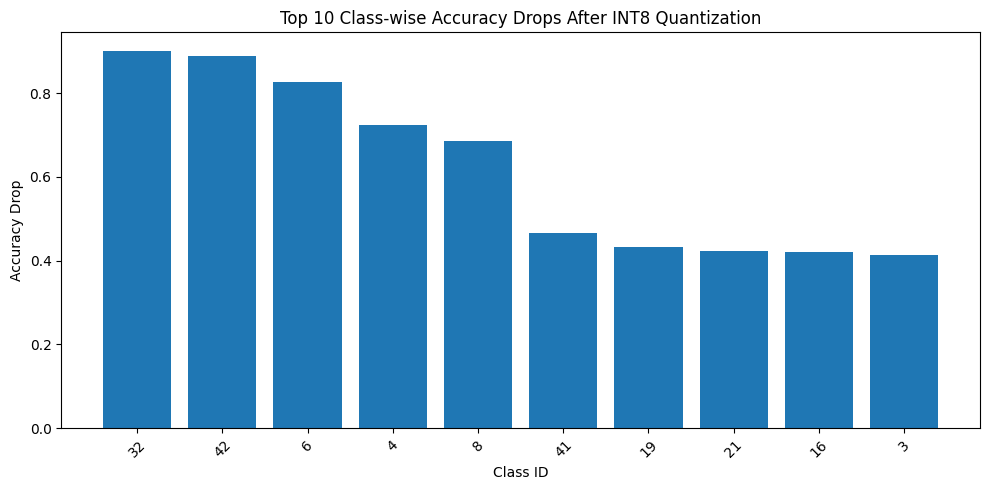

In [42]:
top10Int8Drop = classComparison.sort_values(
    by="INT8_Drop",
    ascending=False
).head(10)

plt.figure(figsize=(10, 5))
plt.bar(top10Int8Drop["ClassId"].astype(str), top10Int8Drop["INT8_Drop"])
plt.xlabel("Class ID")
plt.ylabel("Accuracy Drop")
plt.title("Top 10 Class-wise Accuracy Drops After INT8 Quantization")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Bar plot: FP16 drop

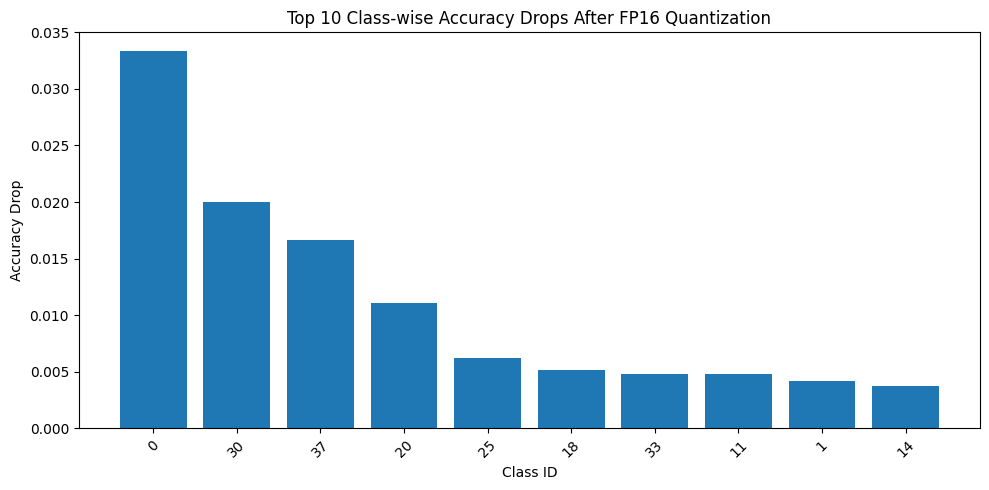

In [43]:
top10Fp16Drop = classComparison.sort_values(
    by="FP16_Drop",
    ascending=False
).head(10)

plt.figure(figsize=(10, 5))
plt.bar(top10Fp16Drop["ClassId"].astype(str), top10Fp16Drop["FP16_Drop"])
plt.xlabel("Class ID")
plt.ylabel("Accuracy Drop")
plt.title("Top 10 Class-wise Accuracy Drops After FP16 Quantization")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### INT8 shrinks and speeds up the model, but it completely breaks some classes. FP16, on the other hand, shrinks the model while largely preserving accuracy, calibration, and class-wise behavior.

#### - The large accuracy drop in INT8 PTQ is likely not just about model size. It also seems related to how quantization affects the fine-tuned feature distributions.

#### - Even though MobileNetV2 is already a lightweight model, INT8 quantization caused a major loss in performance.  FP16, on the other hand, preserved both accuracy and class-wise behavior much better.

### Which classes does INT8 gravitate towards when it makes an incorrect prediction?

- For example: "It can't correctly identify Class 42; it mostly mistakes it for Class X."

### Confusion Matrix

In [47]:
fp32Cm = confusion_matrix(fp32YTrue, fp32YPred, labels=np.arange(43))
int8Cm = confusion_matrix(int8YTrue, int8YPred, labels=np.arange(43))
fp16Cm = confusion_matrix(fp16YTrue, fp16YPred, labels=np.arange(43))

### Find out where INT8 gets most confused for each class

In [48]:
def getTopConfusions(confusionMatrix, classId, topK=5):
    row = confusionMatrix[classId].copy()
    
    correctCount = row[classId]
    row[classId] = 0
    
    topPredictedClasses = np.argsort(row)[::-1][:topK]
    
    rows = []
    
    for predClass in topPredictedClasses:
        count = row[predClass]
        
        if count > 0:
            rows.append({
                "True_Class": classId,
                "Predicted_Class": predClass,
                "Count": count,
                "Correct_Count": correctCount
            })
    
    return pd.DataFrame(rows)

### Generates a confusion matrix for the most frequently broken classes in INT8

In [ ]:
worstClassIds = [32, 42, 6, 4, 8, 41, 19, 21, 16, 3]

In [50]:
allInt8Confusions = []

for classId in worstClassIds:
    classConfusions = getTopConfusions(int8Cm, classId, topK=5)
    allInt8Confusions.append(classConfusions)

allInt8Confusions = pd.concat(allInt8Confusions, ignore_index=True)

allInt8Confusions

,True_Class,Predicted_Class,Count,Correct_Count
0,32,25,30,6
1,32,13,13,6
2,32,12,9,6
3,32,11,2,6
4,42,10,23,0
5,42,11,19,0
6,42,3,15,0
7,42,25,9,0
8,42,41,6,0
9,6,25,50,6


### which class confusions increased the most after INT8 quantization

In [51]:
cmDifference = int8Cm - fp32Cm

In [52]:
def getTopIncreasedConfusions(cmDifference, topK=20):
    rows = []
    
    for trueClass in range(cmDifference.shape[0]):
        for predClass in range(cmDifference.shape[1]):
            if trueClass == predClass:
                continue
            
            increase = cmDifference[trueClass, predClass]
            
            if increase > 0:
                rows.append({
                    "True_Class": trueClass,
                    "Predicted_Class": predClass,
                    "Increase_In_Errors": increase
                })
    
    result = pd.DataFrame(rows)
    return result.sort_values(by="Increase_In_Errors", ascending=False).head(topK)

In [53]:
topIncreasedInt8Confusions = getTopIncreasedConfusions(cmDifference, topK=20)
topIncreasedInt8Confusions

,True_Class,Predicted_Class,Increase_In_Errors
33,4,1,187
11,2,1,157
22,3,1,157
35,4,3,148
51,5,1,118
78,8,1,98
68,7,3,81
80,8,3,64
95,9,10,56
92,9,3,56


In [ ]:
allInt8Confusions.to_csv(
    RESULTS_DIR / "int8_top_confusions_by_worst_classes.csv",
    index=False
)

topIncreasedInt8Confusions.to_csv(
    RESULTS_DIR / "int8_confusion_increase_vs_fp32.csv",
    index=False
)